  Glucose     BMI     Age Diabetes
0    High     Low   Young       No
1     Low     Low   Young       No
2  Medium  Medium  Middle       No
3     Low     Low     Old       No
4  Medium    High   Young      Yes
Total records: 100


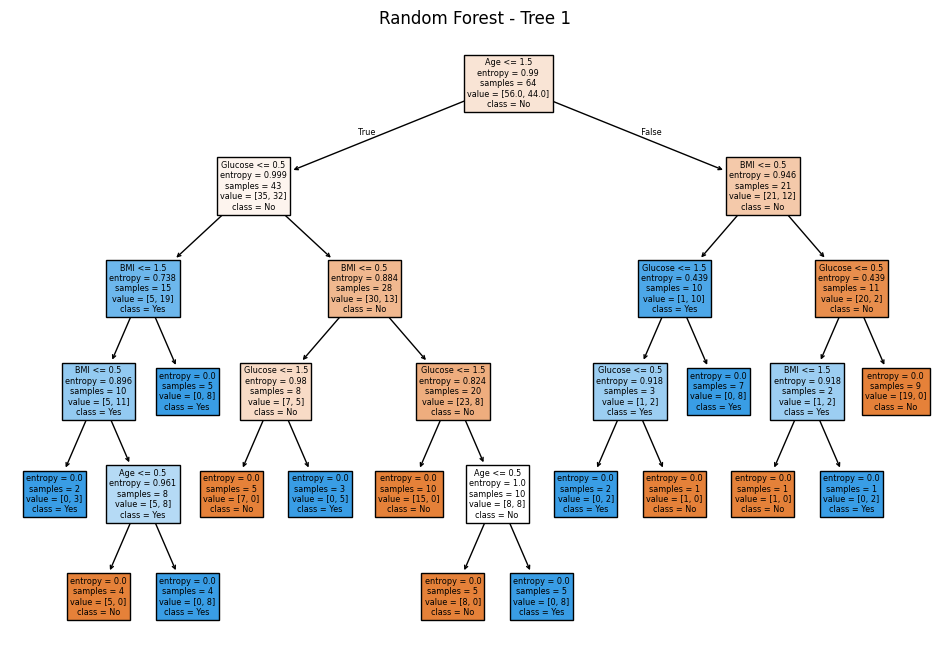

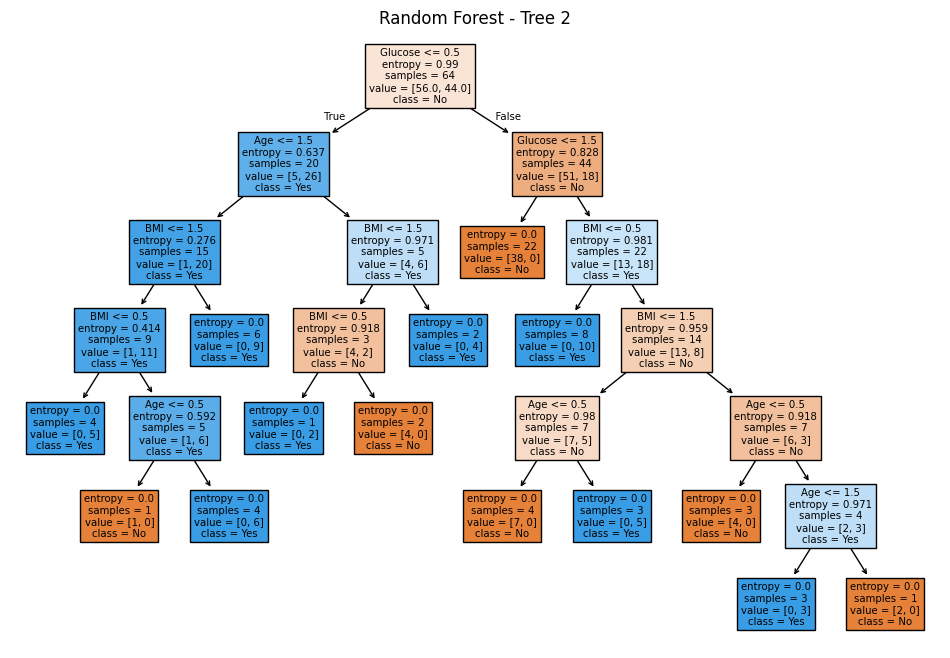

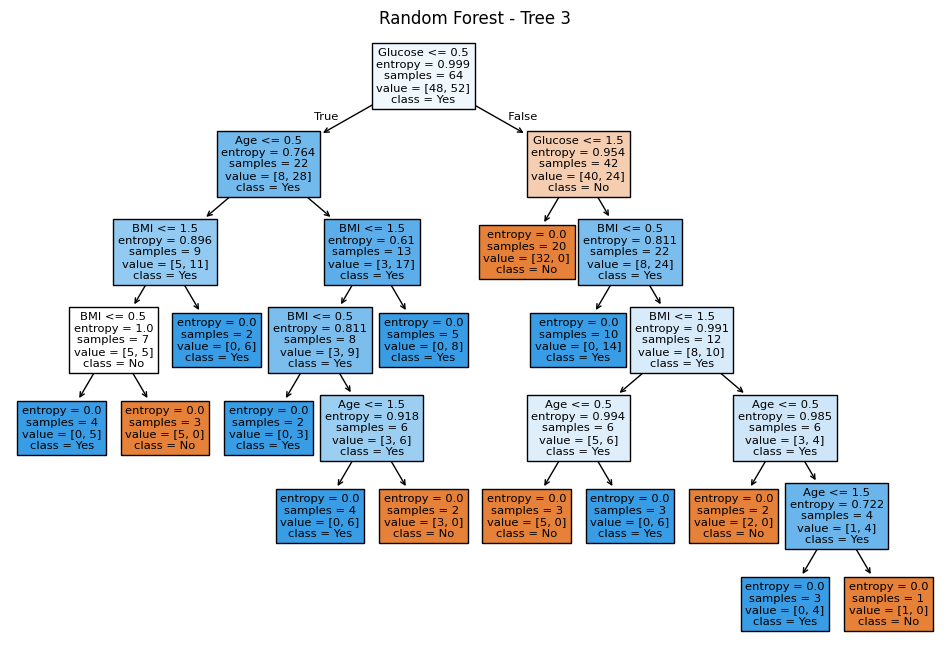

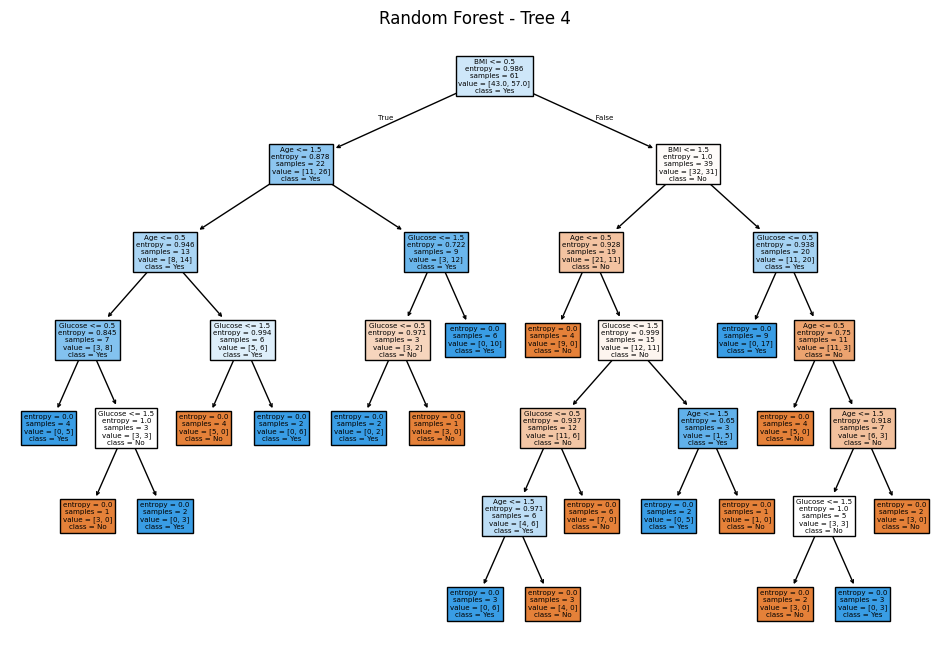

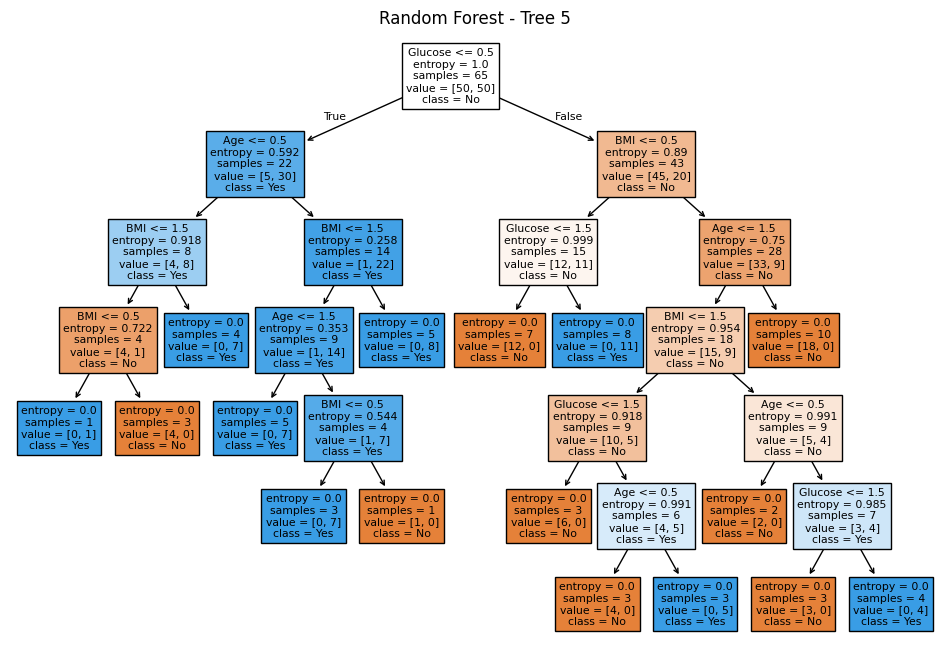

In [1]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

import pandas as pd
import random

# Possible values
glucose_levels = ['Low', 'Medium', 'High']
bmi_levels = ['Low', 'Medium', 'High']
age_groups = ['Young', 'Middle', 'Old']

data = []

for i in range(100):
    glucose = random.choice(glucose_levels)
    bmi = random.choice(bmi_levels)
    age = random.choice(age_groups)

    # Logical rule to generate realistic Diabetes outcome
    if (glucose == 'High' and bmi != 'Low') or \
       (glucose == 'Medium' and bmi == 'High') or \
       (age == 'Old' and glucose != 'Low'):
        diabetes = 'Yes'
    else:
        diabetes = 'No'

    data.append([glucose, bmi, age, diabetes])

df = pd.DataFrame(data, columns=['Glucose','BMI','Age','Diabetes'])

print(df.head())
print("Total records:", len(df))

# Encode
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

X = df[['Glucose','BMI','Age']]
y = df['Diabetes']

# Train Random Forest with 5 trees
rf = RandomForestClassifier(n_estimators=5, criterion='entropy', random_state=0)
rf.fit(X, y)

# Display all trees
for i in range(len(rf.estimators_)):
    plt.figure(figsize=(12,8))
    plot_tree(rf.estimators_[i],
              feature_names=['Glucose','BMI','Age'],
              class_names=['No','Yes'],
              filled=True)
    plt.title(f"Random Forest - Tree {i+1}")
    plt.show()